# Manual exploration of the datasets created by gpt5.2 and gemini

In [1]:
import sys
from datasets import load_dataset,concatenate_datasets
new_path = r'/home/creux/Documents/AI/VTikz/VariabilityBenchmark'
sys.path.append(new_path)

ds1 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_openaigpt5.2_pk_1_t_0.7_v1.58",split="tikz")
ds2 = load_dataset("CharlyR/vtikz-evaluation", "simpleLLM_benchmark_googlegemini3propreview_pk_1_t_0.7_v1.58",split="tikz")
ds = concatenate_datasets([ds1,ds2])
df =ds.to_pandas()


/home/creux/miniconda3/envs/varbench/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
any(metric==100 for metric in df["TemplateMetric"][0][0])

True

In [3]:
import numpy as np
df = df[df["TemplateMetric"].apply(
    lambda metrics: all(len(metric) > 0 and metric[0] != 100 for metric in metrics)
)]
i=  13


In [4]:
from IPython.display import HTML, display
import base64

def display_images_row(*img_jsons, max_height=300, margin=10):
    imgs = []
    for img in img_jsons:
        if img is None:
            continue
        b64 = base64.b64encode(img["bytes"]).decode("utf-8")
        imgs.append(
            f"<img src='data:image/png;base64,{b64}' "
            f"style='max-height:{max_height}px; margin-right:{margin}px;'>"
        )
    html = "<div style='display:flex; align-items:center;'>" + "".join(imgs) + "</div>"
    display(HTML(html))



In [5]:
i-=  1

In [6]:
import difflib

def single_patch(input: str, prediction: str) -> str:
    """Generates a patch from the given input(which will be splitted) and the prediction"""
    solution_split = prediction.splitlines()
    input_split = input.splitlines()
    current_diff = "\n".join(
        list(difflib.unified_diff(input_split, solution_split, n=0))[2:]
    )
    return current_diff


Make the eyes of the chimpanzee wider, in the shape of an ellipse
chimpanzee_elipse_eyes



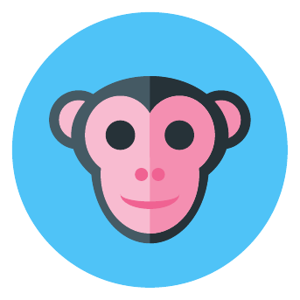
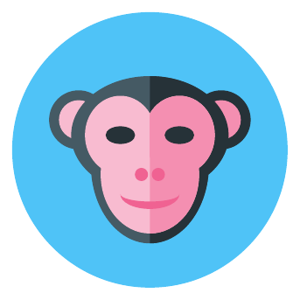
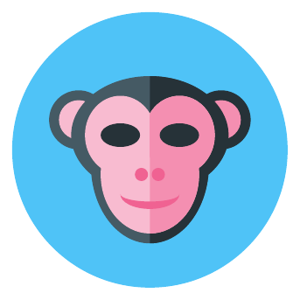

@@ -29 +29 @@

-\fill [BlueGrey900, xscale=\i] (1/2,0) ellipse [radius=1/4];
+\fill [BlueGrey900, xscale=\i] (1/2,0) ellipse [x radius=1/3, y radius=1/5];


In [7]:


i+=1
row = df.iloc[i]
print(row["instruction"])
print(row["id"])
display_images_row(
    row["image_input"],
    row["image_solution"][0],
    row["images_result"][0],
)
open("pred.tex","w").write(row["predictions"][0])
print(single_patch(row["code"],row["predictions"][0]))

In [8]:
row["TemplateMetric"]

array([array([0.], dtype=float32)], dtype=object)

In [9]:
from vtikz.evaluation.template import template_valid,create_default

[open(f"solution{i}.tex","w").write(template) for i,template in enumerate(row["template_solution_code"])]

[template_valid(template,row["predictions"][0]) for template in row["template_solution_code"]]

[False]

In [10]:
single_patch(create_default(row["template_solution_code"][0]),row["predictions"][0])

'@@ -29 +29 @@\n\n-\\fill [BlueGrey900, xscale=\\i] (1/2,0) ellipse [x radius=0.25,y radius=0.15];\n+\\fill [BlueGrey900, xscale=\\i] (1/2,0) ellipse [x radius=1/3, y radius=1/5];'

In [ ]:
template_valid(row["template_solution_code"][0],row["predictions"][0])
